## Assignment 5: Multi-layer Neural Network on Synthetic Data（20 marks）

**Task Description**

Complete the code in the blanks to accomplish the following tasks:
   - **Dataset Loading and Plotting**: Split the given dataset into features and labels, and visualize the dataset.
   - **Forward Propagation**: Compute the output value for each layer.
   - **Backward Propagation**: Compute the local gradient of each layer and optimize the weights.

**Model Structure**
   - **Input layer**: Number of feature (3 nodes)
   - **Hidden layer**: 1 layer with 2 nodes
   - **Output layer**: 1 nodes
   - **Activation Function**: Sigmoid function
   - **Loss function**: Cross-entropy

## Task 1. Dataset Loading and Plotting (3 marks)

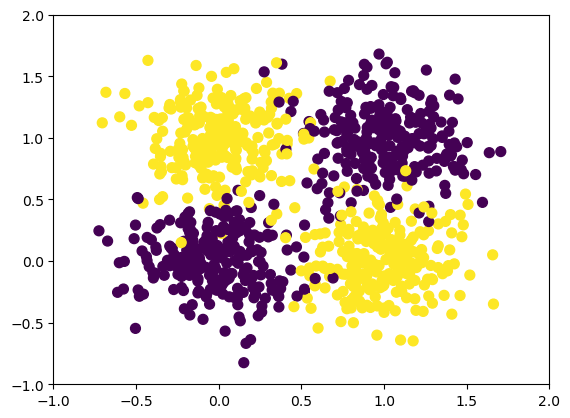

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data_df = pd.read_csv("Syn_data_2D.csv")
#Each data should contain 3 features (Bias, x, y)(concatenate)
data_2D = data_df.to_numpy()[:,:-1]          #----------------------------------------1 marks
y = data_df.to_numpy()[:,-1].reshape(-1, 1)
bias = np.ones((data_2D.shape[0], 1))
data_2D = np.concatenate((bias, data_2D), axis=1)  #----------------------------------------1 marks

fig = plt.figure()
plt.xlim(-1,2)
plt.ylim(-1,2)
plt.scatter(data_2D[:,1],data_2D[:,2], s=50, c=y)         #----------------------------------------1 marks

## Task 2. Training (17 marks)

In [2]:
theta_1 = np.array([[1.0, 0.0],
                    [1.0, 0.0],
                    [1.0, 0.0]])

theta_2 = np.array([1.0, 0.0]).reshape(2,1)
alpha = 0.0001

for epoch in range(5000):
    
    #Forward Propagation
    
    z_1 = data_2D@theta_1        #----------------------------------------1 marks
    a_1 = 1/(1+np.exp(-z_1))        #----------------------------------------1 marks
    z_2 = a_1@theta_2        #----------------------------------------1 marks
    a_2 = 1/(1+np.exp(-z_2))        #----------------------------------------1 marks
    y_pred = a_2


    #Backward Propagation
    
    G1 = ((1-y)/(1-y_pred)-y/y_pred)        #----------------------------------------1 marks
    G2 = 1        #----------------------------------------1 marks
    G3 = a_2*(1-a_2)        #----------------------------------------1 marks

    #Point to theta 2
    G4 = a_1       #----------------------------------------1 marks

    #Point to the activation layer before theta 2
    G5 = theta_2.reshape(-1, 1)       #----------------------------------------1 marks
    G6 = a_1*(1-a_1)       #----------------------------------------1 marks
    G7 = data_2D       #----------------------------------------1 marks

    #Gradient Descent
    grad_theta2 = (((G1*G2*G3).T) @ G4).T # 2*1
    grad_theta1 = G7.T @ (((G1 * G2 * G3).reshape(-1, 1) @ G5.T) * G6) # 3*2
   
    theta_2 = theta_2 - alpha * grad_theta2        #----------------------------------------1 marks
    theta_1 = theta_1 - alpha * grad_theta1        #----------------------------------------2 marks


#Apply the updated weights
z_1 = data_2D@theta_1
a_1 = 1/(1+np.exp(-z_1))
z_2 = a_1@theta_2
a_2 = 1/(1+np.exp(-z_2))
y_pred = a_2 

y_pred_l = []
for i in y_pred:
    if i >= 0.5:             #----------------------------------------1 marks
        y_pred_l.append(1)
    else:
        y_pred_l.append(0)

count = 0
for i in (np.array(y_pred_l)-y.reshape(-1)):
    if(i != 0):             #----------------------------------------1 marks
        count+=1

accuracy = (len(y) - count) / len(y)           #----------------------------------------1 marks
print("Accuracy: " + str(accuracy))

Accuracy: 0.89
